### This notebook compute "E4. Number of livestock production heads" indicator for the 27 basins of IKI Project

Spanish: Número de cabezas de la producción pecuaria

**Created:** 8/4/2025 by Serena Gilson 

**Assumptions:** Uses 'weighted' method to assign values to each COMID based on proportionate area within each district. 

**N/A Handling:** Designate N/A for COMIDs that do not have any livestock activity. 

**Notes:** 
General Methodology:  
1. Determine proportionate area of each district within each COMID.  
2. Calculate the total heads of livestock in each district.  
3. Apply proportionate values to assign livestock counts to COMIDs. 

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

In [6]:
# set master path for input data from config file

config_path = Path("../../config.yaml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

master_path = Path(config["master_path"])

In [9]:
# set up user and database path
db_path = master_path / "Indicadores" / "BD_RiesgoClimatico_IKI.db"

subbasins_shapefile = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Peru_AHD_with_districts.shp"

district_area = master_path / "Indicadores" / "COMID_District_Fractions.csv"

livestockinput_file_path = master_path / "Indicadores" / "Datos_INEI" / "E4_Number of livestock production heads"

In [ ]:
# set up indicator ID and get scenarios from database
IndID= 204 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()


In [12]:
# read in input data 
district_area_within_COMID= pd.read_csv(district_area)

subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

#read in livestock excels  (before reading in, save xls as xlsx as needed)
#ensure they all have a consistent first row/column name of alpacas, ganado_ovino, etc. 

alpacas= pd.read_excel(livestockinput_file_path / 'alpacas.xlsx')
ganado_ovino= pd.read_excel(livestockinput_file_path / 'ganado_ovino.xlsx') 
ganado_porcino= pd.read_excel(livestockinput_file_path / 'ganado_porcino.xlsx')
ganado_vacuno= pd.read_excel(livestockinput_file_path / 'ganado_vacuno.xlsx')
otras_especies= pd.read_excel(livestockinput_file_path / 'otras_especies_cabras_llamas.xlsx')

In [14]:
district_area_within_COMID[district_area_within_COMID["COMID"] == 309690300]

,COMID,DISTRICT,district_area_within_COMID_fraction
6304,309690300,50405,0.000002
6305,309690300,50406,0.164202
6306,309690300,90501,0.137421
6307,309690300,90505,0.193963
6308,309690300,50412,0.000002


In [7]:
#WEIGHTED METHOD FUNCTION 
def calculate_proportionate_values(district_fractions_df, value_df, column_name, comid_list):
    """
    Calculate proportionate values for each COMID based on district area fractions
    
    Parameters:
    - district_fractions_df: DataFrame with COMID, DISTRICT, district_area_within_COMID_fraction
    - value_df: DataFrame with IDDIST and indicator values
    - column_name: Name of the column containing the indicator values
    - comid_list: List of COMIDs to process
    
    Returns:
    - DataFrame with COMID and proportionate_indicator_value
    """
    # Ensure IDDIST and DISTRICT columns are in the same format
    value_df = value_df.copy()
    district_fractions_df = district_fractions_df.copy()
    
    value_df['IDDIST'] = value_df['IDDIST'].astype(str).str.strip()
    district_fractions_df['DISTRICT'] = district_fractions_df['DISTRICT'].astype(str).str.strip()
    
    results = []
    
    for comid in comid_list:
        # Get all districts within this COMID
        districts_in_comid = district_fractions_df[district_fractions_df['COMID'] == comid]
        
        total_proportionate_value = 0
        
        for _, row in districts_in_comid.iterrows():
            district_id = row['DISTRICT']
            fraction = row['district_area_within_COMID_fraction']
            # Get the indicator value for this district
            ind_value = value_df[value_df['IDDIST'] == district_id][column_name].values

            if len(ind_value) > 0:
                # Multiply district value by the fraction of area within COMID
                proportionate_value = ind_value[0] * fraction
                total_proportionate_value += proportionate_value
        
        results.append({
            'COMID': comid,
            'proportionate_indicator_value': total_proportionate_value
        })
    
    return pd.DataFrame(results)

C:\Users\sbakar\AppData\Local\Temp\ipykernel_67280\1496089257.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  livestock.at[livestock.index[i], 'Total_Heads'] = next_row['Unnamed: 1']


Sample of proportionate livestock values:
       COMID  Total_Heads
0  311153600      11763.0
1  310832400      30084.0
2  310825700       3570.0
3  310282400        926.0
4  308754600      12911.0
5  307736500         50.0
6  307078200       6144.0
7  307183500       4214.0
8  306538400       6031.0
9  306599700      36565.0

Total COMIDs: 3655
COMIDs with livestock data (>0): 1934
COMIDs without livestock data (=0): 1721


C:\Users\sbakar\AppData\Local\Temp\ipykernel_67280\1496089257.py:87: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  zero_values.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, label='No Data (0)')
C:\Users\sbakar\AppData\Local\Temp\ipykernel_67280\1496089257.py:97: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


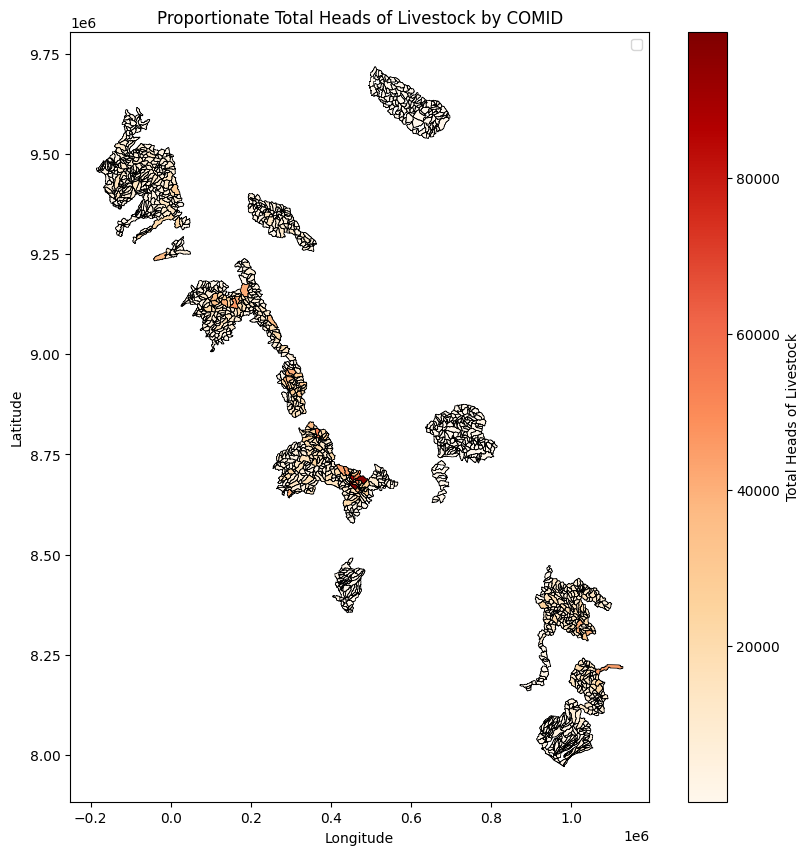

In [8]:
#CLEAN UP DFs FOR PROCESSING AND CALCULATE TOTALS BY DISTRICT

# Initialize an empty DataFrame for cumulative totals
district_totals = pd.DataFrame(columns=['District_ID', 'Total_Heads'])

for livestock_name in ['alpacas', 'ganado_ovino', 'ganado_porcino', 'ganado_vacuno', 'otras_especies']:
    livestock = globals()[livestock_name]  # Access the DataFrame by its name
    livestock= livestock.dropna(axis=1, how='all')  # Drop columns that are completely NaN
    #extract the district name from the livestock dataframe and make a new column with just the district name
    livestock['District']= livestock['Unnamed: 1'].str.split('Dist. ', expand=True)[1].str.strip()
    #remove rows that do not contain 'AREA' or 'Total' in the livestock dataframe
    livestock = livestock[livestock[livestock_name].str.contains('AREA|Total', case=False, na=False)]
    #extract the district # from the livestock dataframe and make a new column with just the district #
    livestock['District_ID'] = livestock[livestock_name].str.split('AREA # ', expand=True)[1].str.strip()
    #remove unnamed:2, 3 and 4 columns
    livestock = livestock.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], errors='ignore')

    # Add a "Total Heads" column initialized with 0
    livestock['Total_Heads'] = 0

    # Collect indices to drop after processing
    indices_to_drop = []

    # Iterate through the rows to check for AREA rows and their corresponding Total rows
    for i in range(len(livestock) - 1):
        if 'AREA' in str(livestock.iloc[i][livestock_name]).upper():
            next_row = livestock.iloc[i + 1]
            if 'TOTAL' in str(next_row[livestock_name]).upper():
                livestock.at[livestock.index[i], 'Total_Heads'] = next_row['Unnamed: 1']
                indices_to_drop.append(livestock.index[i + 1])

    # Drop all marked indices at once
    livestock.drop(index=indices_to_drop, inplace=True)
    livestock.reset_index(drop=True, inplace=True)

    # Convert Total_Heads to numeric
    livestock['Total_Heads'] = pd.to_numeric(livestock['Total_Heads'], errors='coerce').fillna(0)

    # Group by District_ID and sum Total_Heads
    current_totals = livestock.groupby('District_ID', as_index=False).agg({'Total_Heads': 'sum'})

    # Update the cumulative district_totals DataFrame
    district_totals = pd.concat([district_totals, current_totals], ignore_index=True)
    district_totals = district_totals.groupby('District_ID', as_index=False).agg({'Total_Heads': 'sum'})

# Rename District_ID to IDDIST for consistency with weighted method function
district_totals = district_totals.rename(columns={'District_ID': 'IDDIST'})

# Get unique COMIDs from subbasins_gdf
unique_comids = subbasins_gdf['COMID'].unique()

# Calculate proportionate values using weighted method
proportionate_df = calculate_proportionate_values(
    district_area_within_COMID, 
    district_totals, 
    'Total_Heads',
    unique_comids
)

# Merge back to subbasins_gdf
subbasins_gdf = subbasins_gdf.merge(
    proportionate_df, 
    on='COMID', 
    how='left'
)

# Rename column and round to nearest whole number; convert 0s to NaN
subbasins_gdf = subbasins_gdf.rename(columns={'proportionate_indicator_value': 'Total_Heads'})
subbasins_gdf['Total_Heads'] = subbasins_gdf['Total_Heads'].round(0)
subbasins_gdf.loc[subbasins_gdf['Total_Heads'] == 0, 'Total_Heads'] = np.nan

# Display results
print("Sample of proportionate livestock values:")
print(subbasins_gdf[['COMID', 'Total_Heads']].head(10))
print(f"\nTotal COMIDs: {len(subbasins_gdf)}")
print(f"COMIDs with livestock data (>0): {(subbasins_gdf['Total_Heads'] > 0).sum()}")
print(f"COMIDs without livestock data (=0): {(subbasins_gdf['Total_Heads'].isna()).sum()}")

#VISUALIZE 
fig, ax = plt.subplots(figsize=(10, 10))

# Separate zero and non-zero values
zero_values = subbasins_gdf[subbasins_gdf['Total_Heads'] == 0]
nonzero_values = subbasins_gdf[subbasins_gdf['Total_Heads'] > 0]

# Plot zero values in grey
zero_values.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.5, label='No Data (0)')

# Plot non-zero values with color ramp
nonzero_values.plot(column='Total_Heads', ax=ax, cmap='OrRd', 
                    legend=True, edgecolor='black', linewidth=0.5,
                    legend_kwds={'label': 'Total Heads of Livestock'})

plt.title('Proportionate Total Heads of Livestock by COMID')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

C:\Users\sbakar\AppData\Local\Temp\ipykernel_67280\902259693.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  majority_totals['Majority_Total_Heads'] = majority_totals['Majority_Total_Heads'].fillna(0)
C:\Users\sbakar\AppData\Local\Temp\ipykernel_67280\902259693.py:75: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  zero_w.plot(ax=ax1, color='lightgrey', edgecolor='black', linewidth=0.5)


COMPARISON: Weighted Method vs. Majority District Method

Total COMIDs: 3655

Weighted Method:
  Total livestock heads: 8,579,245
  Average per COMID: 4,436
  COMIDs with data (>0): 1934

Majority District Method:
  Total livestock heads: 57,091,215
  Average per COMID: 16,023
  COMIDs with data (>0): 1834

Difference (Weighted - Majority):
  Total difference: -48,503,314
  Average difference: -25,079
  Std deviation: 35,079
  COMIDs with higher weighted values: 284
  COMIDs with lower weighted values: 1650
  COMIDs with same values: 0

Top 10 COMIDs with Largest Absolute Differences:
    COMID  Weighted_Total_Heads  Majority_Total_Heads  Difference  Percent_Difference
309278000               85933.0               12062.0     73871.0          612.427458
309291700               96993.0               23773.0     73220.0          307.996467
309361800               98782.0               33833.0     64949.0          191.969379
308796200               54255.0               19900.0     34355.

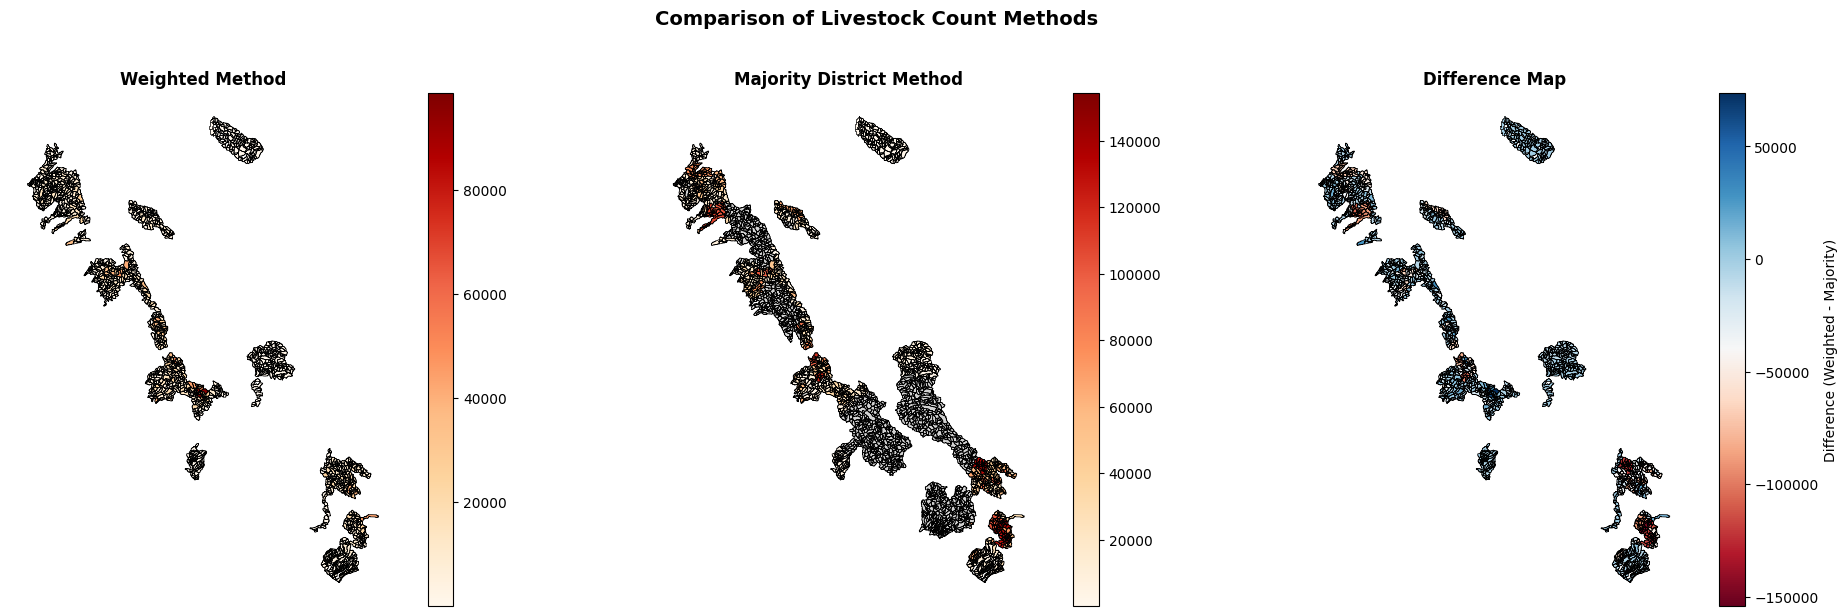

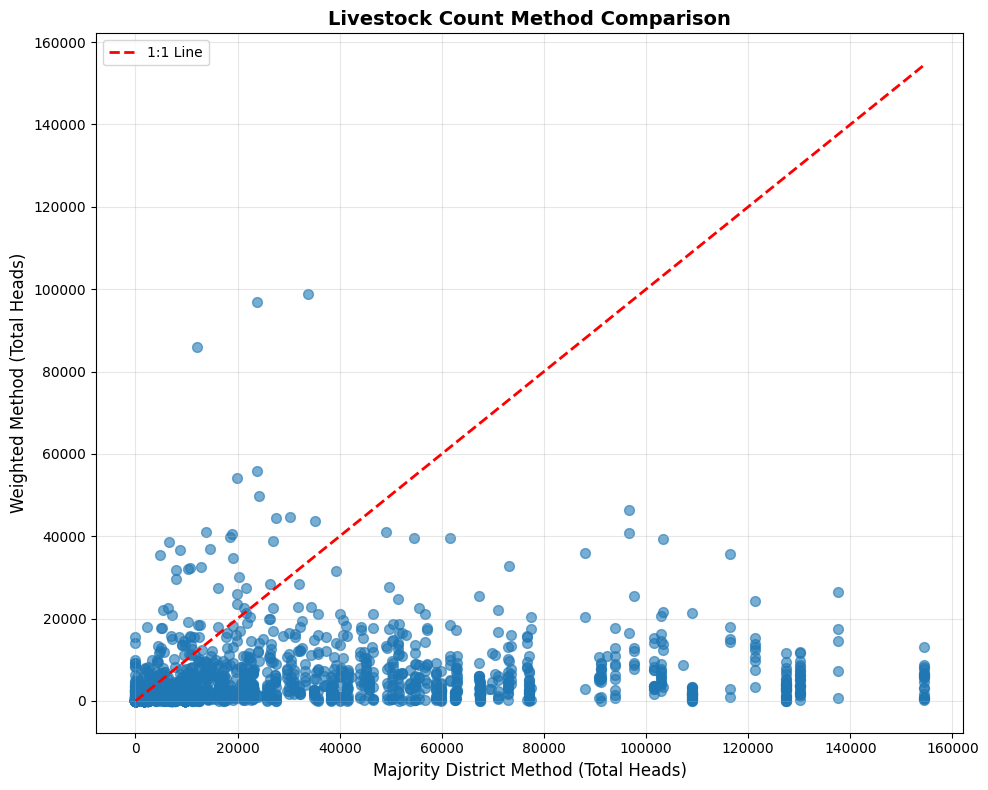

In [9]:
# Create comparison between weighted method and majority district method

# Method 1: Weighted/Proportionate method (already calculated)
weighted_totals = subbasins_gdf[['COMID', 'Total_Heads']].copy()
weighted_totals = weighted_totals.rename(columns={'Total_Heads': 'Weighted_Total_Heads'})

# Method 2: Majority district method
# For each COMID, use the district with the largest area fraction
majority_district = district_area_within_COMID.loc[
    district_area_within_COMID.groupby('COMID')['district_area_within_COMID_fraction'].idxmax()
][['COMID', 'DISTRICT']]

# Ensure DISTRICT format matches IDDIST in district_totals
majority_district['DISTRICT'] = majority_district['DISTRICT'].astype(str).str.strip()

# Merge with district totals to get livestock counts
majority_totals = majority_district.merge(
    district_totals,
    left_on='DISTRICT',
    right_on='IDDIST',
    how='left'
)
majority_totals = majority_totals[['COMID', 'Total_Heads']].rename(
    columns={'Total_Heads': 'Majority_Total_Heads'}
)
majority_totals['Majority_Total_Heads'] = majority_totals['Majority_Total_Heads'].fillna(0)

# Merge both methods for comparison
comparison_df = weighted_totals.merge(majority_totals, on='COMID', how='left')
comparison_df['Difference'] = comparison_df['Weighted_Total_Heads'] - comparison_df['Majority_Total_Heads']
comparison_df['Percent_Difference'] = np.where(
    comparison_df['Majority_Total_Heads'] > 0,
    (comparison_df['Difference'] / comparison_df['Majority_Total_Heads']) * 100,
    np.nan
)

# Summary statistics
print("=" * 80)
print("COMPARISON: Weighted Method vs. Majority District Method")
print("=" * 80)
print(f"\nTotal COMIDs: {len(comparison_df)}")
print(f"\nWeighted Method:")
print(f"  Total livestock heads: {comparison_df['Weighted_Total_Heads'].sum():,.0f}")
print(f"  Average per COMID: {comparison_df['Weighted_Total_Heads'].mean():,.0f}")
print(f"  COMIDs with data (>0): {(comparison_df['Weighted_Total_Heads'] > 0).sum()}")
print(f"\nMajority District Method:")
print(f"  Total livestock heads: {comparison_df['Majority_Total_Heads'].sum():,.0f}")
print(f"  Average per COMID: {comparison_df['Majority_Total_Heads'].mean():,.0f}")
print(f"  COMIDs with data (>0): {(comparison_df['Majority_Total_Heads'] > 0).sum()}")
print(f"\nDifference (Weighted - Majority):")
print(f"  Total difference: {comparison_df['Difference'].sum():,.0f}")
print(f"  Average difference: {comparison_df['Difference'].mean():,.0f}")
print(f"  Std deviation: {comparison_df['Difference'].std():,.0f}")
print(f"  COMIDs with higher weighted values: {(comparison_df['Difference'] > 0).sum()}")
print(f"  COMIDs with lower weighted values: {(comparison_df['Difference'] < 0).sum()}")
print(f"  COMIDs with same values: {(comparison_df['Difference'] == 0).sum()}")

# Display sample of largest differences
print("\n" + "=" * 80)
print("Top 10 COMIDs with Largest Absolute Differences:")
print("=" * 80)
top_diff = comparison_df.nlargest(10, 'Difference')[
    ['COMID', 'Weighted_Total_Heads', 'Majority_Total_Heads', 'Difference', 'Percent_Difference']
]
print(top_diff.to_string(index=False))

# Visualization: Side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Weighted method
ax1 = axes[0]
subbasins_weighted = subbasins_gdf.merge(weighted_totals, on='COMID', how='left')
zero_w = subbasins_weighted[subbasins_weighted['Weighted_Total_Heads'] == 0]
nonzero_w = subbasins_weighted[subbasins_weighted['Weighted_Total_Heads'] > 0]
zero_w.plot(ax=ax1, color='lightgrey', edgecolor='black', linewidth=0.5)
nonzero_w.plot(column='Weighted_Total_Heads', ax=ax1, cmap='OrRd', 
               legend=True, edgecolor='black', linewidth=0.5)
ax1.set_title('Weighted Method', fontsize=12, fontweight='bold')
ax1.axis('off')

# Plot 2: Majority district method
ax2 = axes[1]
subbasins_majority = subbasins_gdf.merge(majority_totals, on='COMID', how='left')
zero_m = subbasins_majority[subbasins_majority['Majority_Total_Heads'] == 0]
nonzero_m = subbasins_majority[subbasins_majority['Majority_Total_Heads'] > 0]
zero_m.plot(ax=ax2, color='lightgrey', edgecolor='black', linewidth=0.5)
nonzero_m.plot(column='Majority_Total_Heads', ax=ax2, cmap='OrRd', 
               legend=True, edgecolor='black', linewidth=0.5)
ax2.set_title('Majority District Method', fontsize=12, fontweight='bold')
ax2.axis('off')

# Plot 3: Difference map
ax3 = axes[2]
subbasins_diff = subbasins_gdf.merge(comparison_df[['COMID', 'Difference']], on='COMID', how='left')
subbasins_diff.plot(column='Difference', ax=ax3, cmap='RdBu', 
                    legend=True, edgecolor='black', linewidth=0.5,
                    legend_kwds={'label': 'Difference (Weighted - Majority)'})
ax3.set_title('Difference Map', fontsize=12, fontweight='bold')
ax3.axis('off')

plt.suptitle('Comparison of Livestock Count Methods', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Scatter plot comparison
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(comparison_df['Majority_Total_Heads'], 
           comparison_df['Weighted_Total_Heads'],
           alpha=0.6, s=50)
max_val = max(comparison_df['Majority_Total_Heads'].max(), 
              comparison_df['Weighted_Total_Heads'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='1:1 Line')
ax.set_xlabel('Majority District Method (Total Heads)', fontsize=12)
ax.set_ylabel('Weighted Method (Total Heads)', fontsize=12)
ax.set_title('Livestock Count Method Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Insert results into the database
insert_data= subbasins_gdf #COMID 
value_column= 'Total_Heads' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [11]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['Total_Heads']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 204  Min: 0, Max: 10000000

=== Values to be inserted (by scenario) ===
   index  Total_Heads
0    min          1.0
1    max      98782.0
2  count       1934.0
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [12]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()